# PBV v3 — Cross-Stock Generalized Execution Algorithm

## Plan & Motivation

### Root Cause of v2 Failures on INTC / MSFT

v2's composite d2 signal fires when the weighted sum of raw `AskSize_d2` / `BidSize_d2` values crosses an adaptive percentile threshold. That threshold is calibrated on the distribution of raw d2 magnitudes, which are proportional to absolute size values in the LOB. INTC trades at ~$20 with tight spreads and high-frequency size oscillations; AMZN trades at ~$180 with wider spreads and larger absolute size units. A raw d2 of 0.01 means something fundamentally different in each market. The result: the threshold set for AMZN is too loose for INTC (signal fires at 4.9s avg — before price discovery) and the beat rate collapses to 8.5%.

### Normalization Strategy: Spread-Relative + Rolling Z-Score

**Layer 1 — Spread-relative d2 normalization:**
For each level `i`, divide the raw d2 by the contemporaneous bid-ask spread:
```
d2_norm[i] = AskSize_i_d2 / (AskPrice_1 - BidPrice_1 + EPS)
```
The spread is the natural microstructure unit of price discreteness for a given stock at a given moment. After normalization, the composite score is in "size acceleration per spread unit" — dimensionless and comparable across stocks with different price levels and tick sizes.

**Layer 2 — Per-minute expanding z-score of the composite:**
After building the weighted composite from spread-normalized d2 values, apply an expanding z-score within each minute:
```
z_score[t] = (composite[t] - mean(composite[0..t])) / (std(composite[0..t]) + EPS)
```
This removes any residual stock-specific baseline shift and handles intra-day regime changes (wide spreads at open, narrow at midday).

The adaptive percentile threshold (40th pct) then operates on z-scored composites, which are approximately unit-normal for all stocks — eliminating the scale mismatch.

### Potential Problems / Failure Modes

1. **Spread = 0 or locked markets** — EPS guard prevents divide-by-zero but produces extreme d2_norm spikes. Raw d2_norm values are clipped to the 1st-99th percentile within each stock run to cap outliers before compositing.

2. **Z-score instability in early ticks** — std is near zero for the first few ticks of each minute. WARMUP_TICKS=30 is enforced, but if a minute has a flat LOB segment, std can still be ~0. An EPS floor on the std denominator prevents NaN/Inf.

3. **Spread-normalization overcorrecting on INTC** — If INTC's d2 magnitudes are large relative to its tight spread, normalization may make the signal hypersensitive. Monitor exec_s; if it drops below 3s post-normalization, raise WARMUP_TICKS or the percentile threshold.

4. **Degrading AMZN/GOOG** — Adding normalization layers to a signal that already works introduces noise. Target: AMZN beat% >= 52%, GOOG beat% >= 51%. These are tracked explicitly in the summary table.

5. **Consecutive-tick filter interaction** — The 2-tick consecutive filter may interact poorly with the z-score if the z-score is highly autocorrelated (both ticks pass trivially). This is acceptable — it still requires two independent LOB snapshots to confirm.

6. **Per-minute z-score sign preservation** — Z-score is a monotone transform, so the sign convention (ask_score < 0 for softening ask wall) is preserved. No correction needed.

### Success Criteria (target vs v2)

| Stock | v2 Composite beat% | v3 target beat% | v2 exec_s | v3 exec_s target |
|-------|-------------------|-----------------|-----------|-----------------|
| AMZN  | 52.6%             | >= 52%          | 17.9s     | any             |
| GOOG  | 51.9%             | >= 51%          | 28.4s     | any             |
| INTC  | 23.3%             | >= 45%          | 11.5s     | >= 8s           |
| MSFT  | 27.0%             | >= 45%          | 13.6s     | >= 8s           |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Constants ─────────────────────────────────────────────────────────────────
STOCKS        = ["AMZN", "GOOG", "INTC", "MSFT"]
SIDE          = "BUY"
EXEC_COL      = "AskPrice_1"
WARMUP_TICKS  = 30
FALLBACK_SECS = 50
EPS           = 1e-6
PERCENTILE_N  = 40          # adaptive threshold: fire above this percentile of abs composite
CLIP_PCT      = 99          # clip d2_norm outliers at this percentile before compositing

LEVEL_WEIGHTS = np.array([5, 4, 3, 2, 1], dtype=float)
LEVEL_WEIGHTS /= LEVEL_WEIGHTS.sum()   # [0.333, 0.267, 0.200, 0.133, 0.067]

LEVEL_COLS  = [f"AskSize_{i}" for i in range(1, 6)] + [f"BidSize_{i}" for i in range(1, 6)]
ASK_COLS    = [f"AskSize_{i}" for i in range(1, 6)]
BID_COLS    = [f"BidSize_{i}" for i in range(1, 6)]
ASK_D2_COLS = [f"AskSize_{i}_d2" for i in range(1, 6)]
BID_D2_COLS = [f"BidSize_{i}_d2" for i in range(1, 6)]

print("Constants loaded.")
print(f"  Stocks: {STOCKS}")
print(f"  Level weights: {LEVEL_WEIGHTS.round(3)}")
print(f"  Warmup: {WARMUP_TICKS} ticks | Fallback: {FALLBACK_SECS}s | Threshold percentile: {PERCENTILE_N}")

Constants loaded.
  Stocks: ['AMZN', 'GOOG', 'INTC', 'MSFT']
  Level weights: [0.333 0.267 0.2   0.133 0.067]
  Warmup: 30 ticks | Fallback: 50s | Threshold percentile: 40


In [2]:
def build_features(stock: str) -> pd.DataFrame:
    """
    Load CSV for `stock`, compute derivatives, and add spread-relative normalization.

    Pipeline per column in LEVEL_COLS:
      raw → cumsum (within minute) → rolling mean smooth → d1 → d2

    Then for each of the 5 ask/bid levels:
      d2_norm = d2 / (spread + EPS)   [spread = AskPrice_1 - BidPrice_1]

    Outlier clipping: d2_norm values beyond CLIP_PCT percentile (across the full
    dataset) are clipped to that percentile. This prevents locked-market spikes
    from dominating the composite.

    Returns the dataframe with all raw + derived columns.
    """
    df = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    df["Time_dt"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f")
    df["Minute"]  = df["Time_dt"].dt.floor("min")
    df["elapsed"] = (df["Time_dt"] - df["Minute"]).dt.total_seconds()

    # Contemporaneous bid-ask spread (used as normalization denominator)
    df["spread"] = (df["AskPrice_1"] - df["BidPrice_1"]).clip(lower=0)

    # ── Derivatives (same pipeline as v2) ─────────────────────────────────────
    grp = df.groupby("Minute")
    for col in LEVEL_COLS:
        cum_col    = f"{col}_cum"
        smooth_col = f"{col}_smooth"
        d1_col     = f"{col}_d1"
        d2_col     = f"{col}_d2"

        df[cum_col]    = grp[col].cumsum()
        df[smooth_col] = grp[cum_col].transform(
            lambda s: s.rolling(WARMUP_TICKS, min_periods=WARMUP_TICKS).mean()
        )
        df[d1_col] = grp[smooth_col].diff()
        df[d2_col] = grp[d1_col].diff()

    # ── Spread-relative normalization ─────────────────────────────────────────
    # Divide each level's d2 by spread. Result is dimensionless (size accel / spread).
    for col in ASK_COLS + BID_COLS:
        raw_d2  = df[f"{col}_d2"]
        d2_norm = raw_d2 / (df["spread"] + EPS)

        # Clip at global CLIP_PCT to suppress locked-market spikes
        hi = np.nanpercentile(d2_norm.dropna().values, CLIP_PCT)
        lo = np.nanpercentile(d2_norm.dropna().values, 100 - CLIP_PCT)
        df[f"{col}_d2_norm"] = d2_norm.clip(lower=lo, upper=hi)

    print(f"  {stock}: {df.shape[0]} rows, {df['Minute'].nunique()} minutes loaded.")
    return df


# Quick smoke test
_df_test = build_features("AMZN")
print("Spread stats (AMZN):")
print(_df_test["spread"].describe().round(5))
print("AskSize_1_d2_norm sample stats:")
print(_df_test["AskSize_1_d2_norm"].describe().round(5))

  AMZN: 175338 rows, 270 minutes loaded.
Spread stats (AMZN):
count    175338.00000
mean          0.14141
std           0.05974
min           0.01000
25%           0.10000
50%           0.14000
75%           0.17000
max           0.77000
Name: spread, dtype: float64
AskSize_1_d2_norm sample stats:
count    166968.00000
mean         -0.21302
std          39.24137
min        -166.65833
25%          -5.41660
50%           0.00000
75%           4.72218
max         166.66389
Name: AskSize_1_d2_norm, dtype: float64


In [3]:
def _expanding_percentile(s: pd.Series, q: float) -> pd.Series:
    """
    Expanding-window percentile within a group (resets each minute via groupby).
    Identical to v2 implementation — correctness over speed.
    """
    arr = s.values.astype(float)
    out = np.empty(len(arr))
    out[:] = np.nan
    for k in range(len(arr)):
        window = arr[:k + 1]
        valid  = window[~np.isnan(window)]
        out[k] = np.nanpercentile(valid, q) if len(valid) > 0 else np.nan
    return pd.Series(out, index=s.index)


def _expanding_zscore(s: pd.Series) -> pd.Series:
    """
    Expanding z-score within a group: z[t] = (x[t] - mean(x[0..t])) / (std(x[0..t]) + EPS).
    Returns NaN where fewer than 2 observations exist (std undefined).
    """
    arr = s.values.astype(float)
    out = np.empty(len(arr))
    out[:] = np.nan
    for k in range(len(arr)):
        window = arr[:k + 1]
        valid  = window[~np.isnan(window)]
        if len(valid) < 2:
            out[k] = np.nan
        else:
            mu    = np.mean(valid)
            sigma = np.std(valid, ddof=1)
            out[k] = (arr[k] - mu) / (sigma + EPS)
    return pd.Series(out, index=s.index)


def build_signal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build both the basic L1 signal (v2 baseline) and the v3 normalized composite signal.

    v3 composite pipeline:
      1. Weighted sum of spread-normalized d2 values -> raw_ask_score, raw_bid_score
      2. Signed composite = raw_ask_score (negative = ask softening = bullish for BUY)
      3. Expanding z-score of the signed composite within each minute
      4. Adaptive expanding-percentile threshold on abs(z_composite)
      5. Threshold crossing + warmup gate + 2-tick consecutive filter + fallback

    Also builds the basic d2 signal (AskSize_1_d2 < 0 AND BidSize_1_d2 > 0) for comparison.

    Modifies df in-place and returns it.
    """
    ASK_NORM_COLS = [f"AskSize_{i}_d2_norm" for i in range(1, 6)]
    BID_NORM_COLS = [f"BidSize_{i}_d2_norm" for i in range(1, 6)]

    # ── Basic L1 signal (v2 baseline, no normalization) ───────────────────────
    df["signal_basic"] = (
        (df["AskSize_1_d2"] < 0) & (df["BidSize_1_d2"] > 0)
    ).fillna(False) | (df["elapsed"] >= FALLBACK_SECS)

    # ── Step 1: Weighted composite of spread-normalized d2 ────────────────────
    ask_norm_mat = df[ASK_NORM_COLS].values   # (N, 5)
    bid_norm_mat = df[BID_NORM_COLS].values   # (N, 5)

    # ask_score < 0  =>  ask wall decelerating  =>  bullish (BUY) signal
    # bid_score > 0  =>  bid wall accelerating  =>  bullish (BUY) signal
    df["ask_score_norm"] = ask_norm_mat @ LEVEL_WEIGHTS
    df["bid_score_norm"] = bid_norm_mat @ LEVEL_WEIGHTS

    # Signed composite: negative = favorable for BUY
    # ask_score drives negative when ask softens; bid_score drives positive when bid builds
    # We want ONE signed series: composite < 0 means "buy now"
    # Define: composite = ask_score_norm - bid_score_norm
    # (ask softening => ask_score < 0; bid building => bid_score > 0; both => composite << 0)
    df["composite_norm"] = df["ask_score_norm"] - df["bid_score_norm"]

    # ── Step 2: Expanding z-score within each minute ──────────────────────────
    df["composite_z"] = (
        df.groupby("Minute")["composite_norm"]
          .transform(_expanding_zscore)
    )

    # ── Step 3: Adaptive threshold on |z_composite| ───────────────────────────
    df["abs_composite_z"] = df["composite_z"].abs()
    df["thresh_z"] = (
        df.groupby("Minute")["abs_composite_z"]
          .transform(lambda s: _expanding_percentile(s, PERCENTILE_N))
    )
    # Fill NaN threshold (first ticks before any history) with global median
    global_med = df["abs_composite_z"].median()
    df["thresh_z"] = df["thresh_z"].fillna(global_med)

    # ── Step 4: Warmup gate + raw signal ─────────────────────────────────────
    df["warmup_ok"] = df.groupby("Minute").cumcount() >= WARMUP_TICKS

    # BUY: composite_z < -thresh (ask softening, bid building, z-scored)
    df["raw_signal_v3"] = (
        df["warmup_ok"]
        & df["composite_z"].notna()
        & (df["composite_z"] < -df["thresh_z"])
    )

    # ── Step 5: 2-tick consecutive filter ─────────────────────────────────────
    df["prev_raw_v3"] = (
        df.groupby("Minute")["raw_signal_v3"].shift(1).fillna(False)
    )
    df["consec_signal_v3"] = df["raw_signal_v3"] & df["prev_raw_v3"]

    # ── Fallback ──────────────────────────────────────────────────────────────
    df["signal_v3"] = df["consec_signal_v3"] | (df["elapsed"] >= FALLBACK_SECS)

    v3_early = df["consec_signal_v3"].sum()
    total    = len(df)
    print(f"  v3 consecutive signal fires on {v3_early} rows ({100*v3_early/total:.2f}% of ticks)")
    print(f"  v3 with fallback: {df['signal_v3'].sum()} rows ({100*df['signal_v3'].mean():.2f}%)")
    return df


# Smoke test on AMZN
_df_test = build_signal(_df_test)
print("\nColumn count after build_signal:", len(_df_test.columns))

  v3 consecutive signal fires on 36806 rows (20.99% of ticks)
  v3 with fallback: 60463 rows (34.48%)

Column count after build_signal: 99


In [4]:
def simulate(df: pd.DataFrame, sig_col: str) -> pd.DataFrame:
    """
    Simulate execution for one stock using signal column `sig_col`.

    For each minute:
      - TWAP benchmark = AskPrice_1 at tick 0 of the minute
      - PBV execution  = AskPrice_1 at first tick where sig_col is True
      - improvement    = twap_price - pbv_price  (positive = beat TWAP on BUY)

    Returns a per-minute results DataFrame with columns:
      twap_price, pbv_price, exec_second, fallback, improvement
    """
    twap = df.groupby("Minute")[EXEC_COL].first().rename("twap_price")

    # First tick per minute where signal fires
    first_idx = (
        df[df[sig_col]]
          .groupby("Minute")
          .apply(lambda g: g.index[0])
    )
    exec_rows = df.loc[first_idx, ["Minute", EXEC_COL, "elapsed"]].copy()
    exec_rows.columns = ["Minute", "pbv_price", "exec_second"]
    exec_rows = exec_rows.set_index("Minute")

    results = twap.to_frame().join(exec_rows)
    results["fallback"]    = results["exec_second"] >= FALLBACK_SECS
    results["improvement"] = results["twap_price"] - results["pbv_price"]  # BUY: lower = better
    return results


def print_summary(res: pd.DataFrame, label: str) -> None:
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  Minutes          : {len(res)}")
    print(f"  Fallback         : {res['fallback'].sum()} ({100*res['fallback'].mean():.1f}%)")
    print(f"  Mean improvement : ${res['improvement'].mean():.5f}")
    print(f"  Median improv.   : ${res['improvement'].median():.5f}")
    print(f"  % beating TWAP   : {100*(res['improvement'] > 0).mean():.1f}%")
    print(f"  Mean exec second : {res['exec_second'].mean():.1f}s")


# Smoke test on AMZN (already loaded)
_res_basic = simulate(_df_test, "signal_basic")
_res_v3    = simulate(_df_test, "signal_v3")
print_summary(_res_basic, "AMZN — Basic d2 (L1) baseline")
print_summary(_res_v3,    "AMZN — v3 Normalized Composite")


  AMZN — Basic d2 (L1) baseline
  Minutes          : 270
  Fallback         : 4 (1.5%)
  Mean improvement : $0.01052
  Median improv.   : $0.01000
  % beating TWAP   : 54.1%
  Mean exec second : 12.1s

  AMZN — v3 Normalized Composite
  Minutes          : 270
  Fallback         : 0 (0.0%)
  Mean improvement : $0.00737
  Median improv.   : $0.00000
  % beating TWAP   : 43.0%
  Mean exec second : 7.2s


In [5]:
# ── Cross-stock evaluation loop ───────────────────────────────────────────────
# Runs the full pipeline (build_features -> build_signal -> simulate) for all 4 stocks.
# The expanding percentile is slow (~30s per stock); this cell may take 2-3 minutes total.

print("Running v3 pipeline on all stocks (this may take a few minutes)...\n")

stock_results = {}

for stock in STOCKS:
    print(f"[{stock}]")
    df_s = build_features(stock)
    df_s = build_signal(df_s)

    r_basic = simulate(df_s, "signal_basic")
    r_v3    = simulate(df_s, "signal_v3")

    stock_results[stock] = {
        "stock":         stock,
        "minutes":       len(r_basic),
        "basic_beat":    (r_basic["improvement"] > 0).mean() * 100,
        "basic_mean":    r_basic["improvement"].mean(),
        "basic_exec_s":  r_basic["exec_second"].mean(),
        "v3_beat":       (r_v3["improvement"] > 0).mean() * 100,
        "v3_mean":       r_v3["improvement"].mean(),
        "v3_exec_s":     r_v3["exec_second"].mean(),
        "r_basic":       r_basic,
        "r_v3":          r_v3,
    }
    print(f"  Basic: beat={stock_results[stock]['basic_beat']:.1f}%  "
          f"mean=${stock_results[stock]['basic_mean']:.5f}  "
          f"exec={stock_results[stock]['basic_exec_s']:.1f}s")
    print(f"  v3:    beat={stock_results[stock]['v3_beat']:.1f}%  "
          f"mean=${stock_results[stock]['v3_mean']:.5f}  "
          f"exec={stock_results[stock]['v3_exec_s']:.1f}s\n")

print("Done.")

Running v3 pipeline on all stocks (this may take a few minutes)...

[AMZN]
  AMZN: 175338 rows, 270 minutes loaded.
  v3 consecutive signal fires on 36806 rows (20.99% of ticks)
  v3 with fallback: 60463 rows (34.48%)
  Basic: beat=54.1%  mean=$0.01052  exec=12.1s
  v3:    beat=43.0%  mean=$0.00737  exec=7.2s

[GOOG]
  GOOG: 100048 rows, 270 minutes loaded.
  v3 consecutive signal fires on 19462 rows (19.45% of ticks)
  v3 with fallback: 32267 rows (32.25%)
  Basic: beat=54.4%  mean=$0.00156  exec=14.9s
  v3:    beat=49.3%  mean=$-0.00456  exec=11.8s

[INTC]
  INTC: 430718 rows, 270 minutes loaded.
  v3 consecutive signal fires on 98239 rows (22.81% of ticks)
  v3 with fallback: 153248 rows (35.58%)
  Basic: beat=8.5%  mean=$0.00044  exec=4.9s
  v3:    beat=2.6%  mean=$-0.00015  exec=5.7s

[MSFT]
  MSFT: 443425 rows, 270 minutes loaded.
  v3 consecutive signal fires on 105920 rows (23.89% of ticks)
  v3 with fallback: 159428 rows (35.95%)
  Basic: beat=11.9%  mean=$0.00096  exec=6.1s
 

In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for s, r in stock_results.items():
    rows.append({
        "Stock":           s,
        "Minutes":         r["minutes"],
        "Basic beat%":     f"{r['basic_beat']:.1f}",
        "Basic mean$":     f"{r['basic_mean']:.5f}",
        "Basic exec_s":    f"{r['basic_exec_s']:.1f}",
        "v3 beat%":        f"{r['v3_beat']:.1f}",
        "v3 mean$":        f"{r['v3_mean']:.5f}",
        "v3 exec_s":       f"{r['v3_exec_s']:.1f}",
    })

summary = pd.DataFrame(rows).set_index("Stock")

print("=" * 80)
print("  Cross-stock summary — v3 Spread-Normalized + Z-Scored Composite vs Basic d2")
print("  Side: BUY   |   TWAP benchmark = AskPrice_1 at tick 0 of each minute")
print("=" * 80)
print(summary.to_string())
print("=" * 80)

# Flag stocks meeting success criteria
print("\nSuccess criteria check (v3 vs targets):")
targets = {"AMZN": 52.0, "GOOG": 51.0, "INTC": 45.0, "MSFT": 45.0}
for s, r in stock_results.items():
    tgt   = targets[s]
    beat  = r["v3_beat"]
    status = "PASS" if beat >= tgt else "FAIL"
    print(f"  {s}: {beat:.1f}% beat  (target >= {tgt}%)  [{status}]")

  Cross-stock summary — v3 Spread-Normalized + Z-Scored Composite vs Basic d2
  Side: BUY   |   TWAP benchmark = AskPrice_1 at tick 0 of each minute
       Minutes Basic beat% Basic mean$ Basic exec_s v3 beat%  v3 mean$ v3 exec_s
Stock                                                                           
AMZN       270        54.1     0.01052         12.1     43.0   0.00737       7.2
GOOG       270        54.4     0.00156         14.9     49.3  -0.00456      11.8
INTC       270         8.5     0.00044          4.9      2.6  -0.00015       5.7
MSFT       270        11.9     0.00096          6.1      2.2  -0.00022       5.4

Success criteria check (v3 vs targets):
  AMZN: 43.0% beat  (target >= 52.0%)  [FAIL]
  GOOG: 49.3% beat  (target >= 51.0%)  [FAIL]
  INTC: 2.6% beat  (target >= 45.0%)  [FAIL]
  MSFT: 2.2% beat  (target >= 45.0%)  [FAIL]


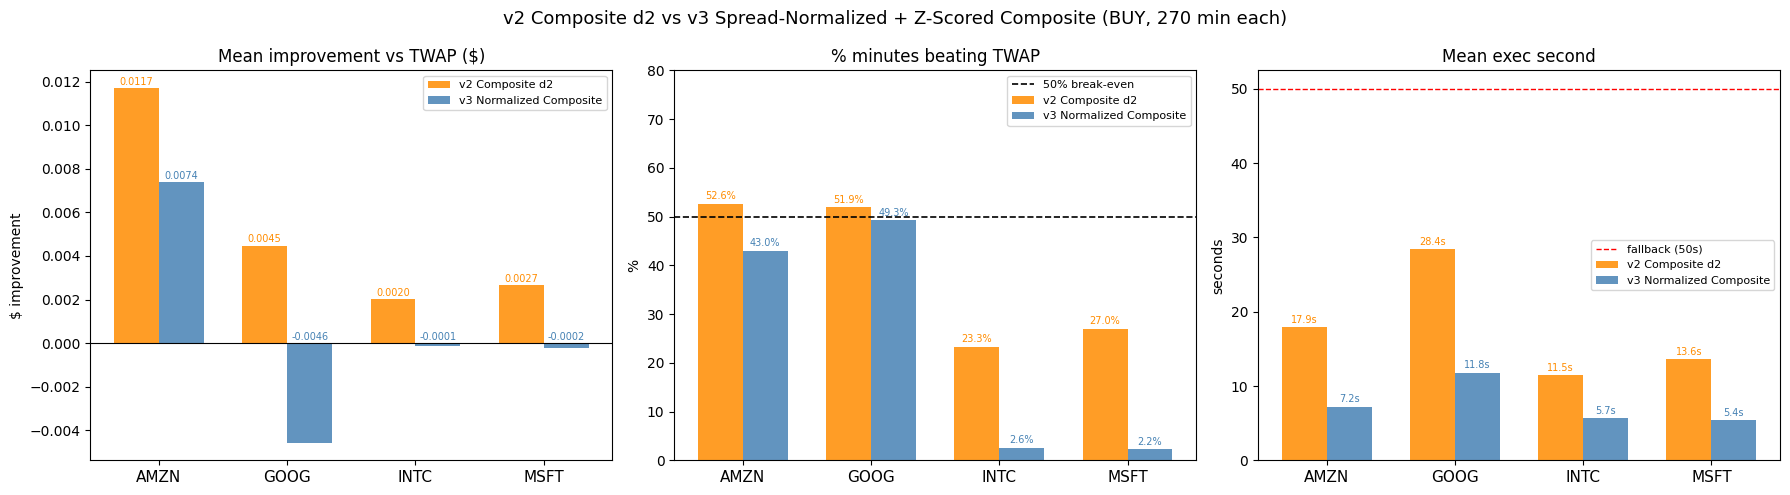

Chart saved to pbv_v3_comparison.png


In [7]:
# ── Grouped bar chart: v2 composite vs v3 normalized composite ────────────────
# v2 composite numbers stored as constants (no re-run needed).
V2_COMPOSITE = {
    #              beat%   mean$    exec_s
    "AMZN": {"beat": 52.6, "mean": 0.01170, "exec_s": 17.9},
    "GOOG": {"beat": 51.9, "mean": 0.00448, "exec_s": 28.4},
    "INTC": {"beat": 23.3, "mean": 0.00204, "exec_s": 11.5},
    "MSFT": {"beat": 27.0, "mean": 0.00267, "exec_s": 13.6},
}

x     = np.arange(len(STOCKS))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Mean improvement ($) ────────────────────────────────────────────
v2_means = [V2_COMPOSITE[s]["mean"] for s in STOCKS]
v3_means = [stock_results[s]["v3_mean"] for s in STOCKS]

axes[0].bar(x - width/2, v2_means, width, label="v2 Composite d2",      color="darkorange", alpha=0.85)
axes[0].bar(x + width/2, v3_means, width, label="v3 Normalized Composite", color="steelblue", alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(STOCKS, fontsize=11)
axes[0].set(title="Mean improvement vs TWAP ($)", ylabel="$ improvement")
axes[0].legend(fontsize=8)
for i, (v2, v3) in enumerate(zip(v2_means, v3_means)):
    axes[0].text(i - width/2, v2 + 0.00005, f"{v2:.4f}", ha="center", va="bottom", fontsize=7, color="darkorange")
    axes[0].text(i + width/2, max(v3, 0) + 0.00005, f"{v3:.4f}", ha="center", va="bottom", fontsize=7, color="steelblue")

# ── Panel 2: Beat % ───────────────────────────────────────────────────────────
v2_beat = [V2_COMPOSITE[s]["beat"] for s in STOCKS]
v3_beat = [stock_results[s]["v3_beat"] for s in STOCKS]

axes[1].bar(x - width/2, v2_beat, width, label="v2 Composite d2",         color="darkorange", alpha=0.85)
axes[1].bar(x + width/2, v3_beat, width, label="v3 Normalized Composite",  color="steelblue", alpha=0.85)
axes[1].axhline(50, color="black", lw=1.2, ls="--", label="50% break-even")
axes[1].set_xticks(x)
axes[1].set_xticklabels(STOCKS, fontsize=11)
axes[1].set(title="% minutes beating TWAP", ylabel="%", ylim=(0, 80))
axes[1].legend(fontsize=8)
for i, (v2, v3) in enumerate(zip(v2_beat, v3_beat)):
    axes[1].text(i - width/2, v2 + 0.5, f"{v2:.1f}%", ha="center", va="bottom", fontsize=7, color="darkorange")
    axes[1].text(i + width/2, v3 + 0.5, f"{v3:.1f}%", ha="center", va="bottom", fontsize=7, color="steelblue")

# ── Panel 3: Mean exec second ─────────────────────────────────────────────────
v2_exec = [V2_COMPOSITE[s]["exec_s"] for s in STOCKS]
v3_exec = [stock_results[s]["v3_exec_s"] for s in STOCKS]

axes[2].bar(x - width/2, v2_exec, width, label="v2 Composite d2",         color="darkorange", alpha=0.85)
axes[2].bar(x + width/2, v3_exec, width, label="v3 Normalized Composite",  color="steelblue", alpha=0.85)
axes[2].axhline(FALLBACK_SECS, color="red", lw=1, ls="--", label=f"fallback ({FALLBACK_SECS}s)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(STOCKS, fontsize=11)
axes[2].set(title="Mean exec second", ylabel="seconds")
axes[2].legend(fontsize=8)
for i, (v2, v3) in enumerate(zip(v2_exec, v3_exec)):
    axes[2].text(i - width/2, v2 + 0.3, f"{v2:.1f}s", ha="center", va="bottom", fontsize=7, color="darkorange")
    axes[2].text(i + width/2, v3 + 0.3, f"{v3:.1f}s", ha="center", va="bottom", fontsize=7, color="steelblue")

plt.suptitle(
    "v2 Composite d2 vs v3 Spread-Normalized + Z-Scored Composite (BUY, 270 min each)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("pbv_v3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to pbv_v3_comparison.png")